# Hate-speech factor sensitivity — primary models

    This compact entry uses the same portable data and computed heatmap as the
    complete notebook. Components are descriptive SD-sized spreads, not
    independent causal variance components.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

ANALYSIS=Path.cwd().parent if Path.cwd().name=='notebooks' else Path.cwd()
if not (ANALYSIS/'data_access.py').exists(): ANALYSIS=Path.cwd()/'tasks'/'hate-speech'/'analysis'
if not (ANALYSIS/'data_access.py').exists(): raise FileNotFoundError('Run from the repository root or hate-speech analysis directory.')
sys.path.insert(0,str(ANALYSIS))
from data_access import read_table, table_path
names=['hs_configuration_scores','hs_factor_sensitivity','hs_item_metrics_by_persona_target','hs_calibration_by_model']
source=table_path(names[0]).parent
try: source=source.relative_to(ANALYSIS.parents[2])
except ValueError: pass
print('Hate-speech analysis source:', source)
scores,sensitivity,metrics,calibration=[read_table(name) for name in names]
model_order=['gemma-3-1b-it','gemma-3-4b-it','gemma-3-12b-it','gemma-3-27b-it',
             'Qwen3-4B','Qwen3-8B','Qwen3-14B','Qwen3-32B']
ideology_order=['base','centrism','libertarian_left','libertarian_right',
                'authoritarian_left','authoritarian_right']
sns.set_theme(style='whitegrid')

Hate-speech analysis source: /tmp/llm-bias-fresh-analysis/data/analysis_ready/hate_speech


## Prompt-factor sensitivity

        `target` is treated as a data-composition block, not a prompt factor.
        Persona wording, context and instruction components are calculated
        within persona conditions. Magnitudes are more informative here than
        tiny p-values produced by the large repeated design.

,model,Mean P(Hate),Total Var SD,Ideology SD,persona_combo_sd,context_combo_sd,instr_combo_sd,Intrinsic Blur,Residual Jitter
0,google/gemma-3-1b-it,0.488,0.428,0.074,0.059,0.067,0.219,0.334,0.106
1,google/gemma-3-4b-it,0.360,0.383,0.115,0.078,0.126,0.094,0.294,0.138
2,google/gemma-3-12b-it,0.414,0.267,0.063,0.048,0.062,0.076,0.225,0.072
3,google/gemma-3-27b-it,0.515,0.234,0.060,0.056,0.038,0.061,0.202,0.055
4,Qwen/Qwen3-4B,0.226,0.373,0.099,0.064,0.076,0.078,0.331,0.065
5,Qwen/Qwen3-8B,0.410,0.415,0.131,0.080,0.136,0.097,0.335,0.101
6,Qwen/Qwen3-14B,0.351,0.295,0.017,0.036,0.026,0.068,0.277,0.053
7,Qwen/Qwen3-32B,0.503,0.384,0.032,0.017,0.046,0.062,0.372,0.045


/Utilisateurs/nchatt01/.conda/envs/absa/lib/python3.11/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/Utilisateurs/nchatt01/.conda/envs/absa/lib/python3.11/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


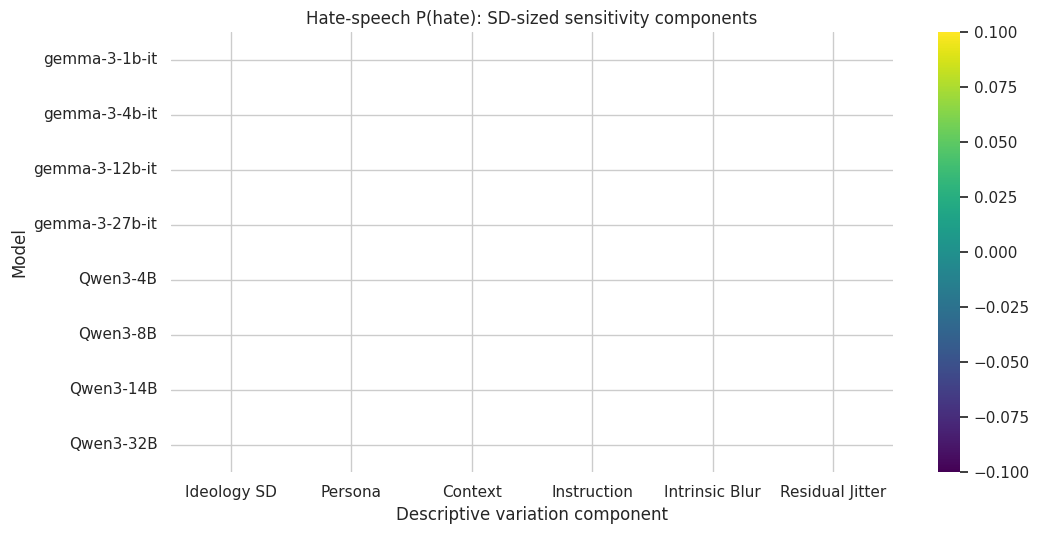

In [2]:
columns=['model','Mean P(Hate)','Total Var SD','Ideology SD','persona_combo_sd',
         'context_combo_sd','instr_combo_sd','Intrinsic Blur','Residual Jitter']
display(sensitivity[columns].round(3))
heat=(sensitivity.set_index('model').reindex(model_order)[
      ['Ideology SD','persona_combo_sd','context_combo_sd','instr_combo_sd','Intrinsic Blur','Residual Jitter']]
      .rename(columns={'persona_combo_sd':'Persona','context_combo_sd':'Context','instr_combo_sd':'Instruction'}))
fig,ax=plt.subplots(figsize=(11,5.5)); sns.heatmap(heat,annot=True,fmt='.3f',cmap='viridis',ax=ax)
ax.set(title='Hate-speech P(hate): SD-sized sensitivity components',
       xlabel='Descriptive variation component',ylabel='Model')
fig.tight_layout(); plt.show()